In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [51]:
df = pd.read_csv('../data/processed/cleaned_hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_family,total_stay,total_guests,lead_time_category
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,False,0,2.0,Early
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,False,0,2.0,Early
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,False,1,1.0,Mid-Term
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,False,1,1.0,Mid-Term
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,False,2,2.0,Mid-Term


In [5]:
# Convert target
df['is_canceled'] = df['is_canceled'].astype(int)


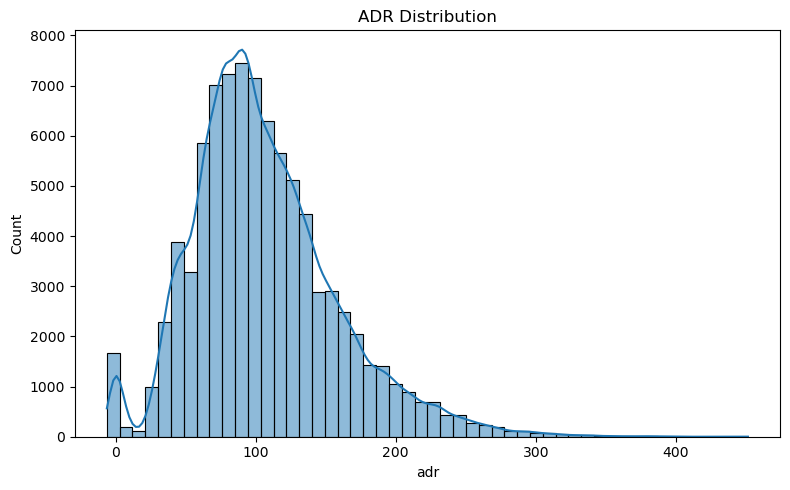

In [55]:
#ADR Distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df['adr'] < 500]['adr'], bins=50, kde=True)
plt.title("ADR Distribution")
plt.tight_layout()
plt.show()

# Most bookings fall within a moderate price range.
# A few high-value outliers exist, indicating premium bookings.

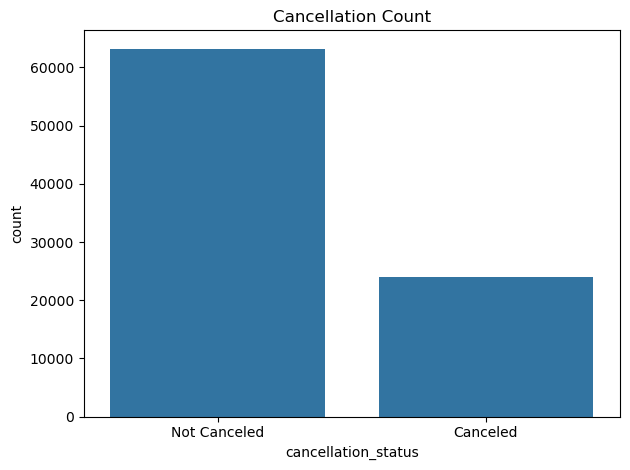

In [57]:
#Cancellation Count
df['cancellation_status'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})
sns.countplot(x='cancellation_status', data=df)
plt.title("Cancellation Count")
plt.tight_layout()
plt.show()

# A significant portion of bookings are canceled.
# Indicates the importance of churn prediction in this dataset.

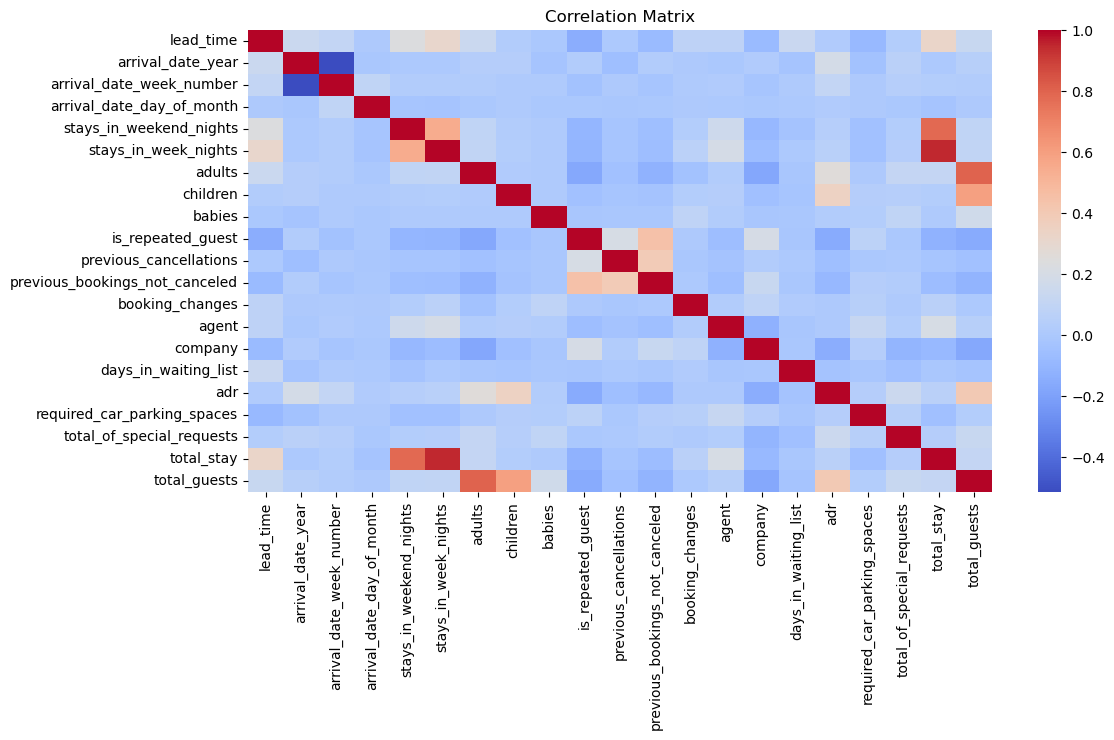

In [59]:
# Correlation Matrix
plt.figure(figsize=(12,6))

corr = numeric_df.corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)

plt.title("Correlation Matrix")
plt.show()

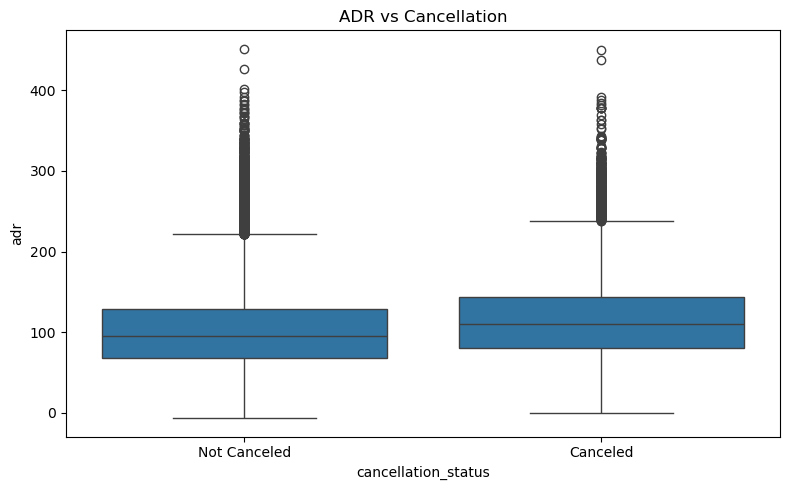

In [23]:
#ADR vs Cancellation
plt.figure(figsize=(8,5))
df['cancellation_status'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})
sns.boxplot(x='cancellation_status', y='adr', data=df)
plt.title("ADR vs Cancellation")
plt.tight_layout()
plt.show()
#Higher ADR may influence cancellation behavior

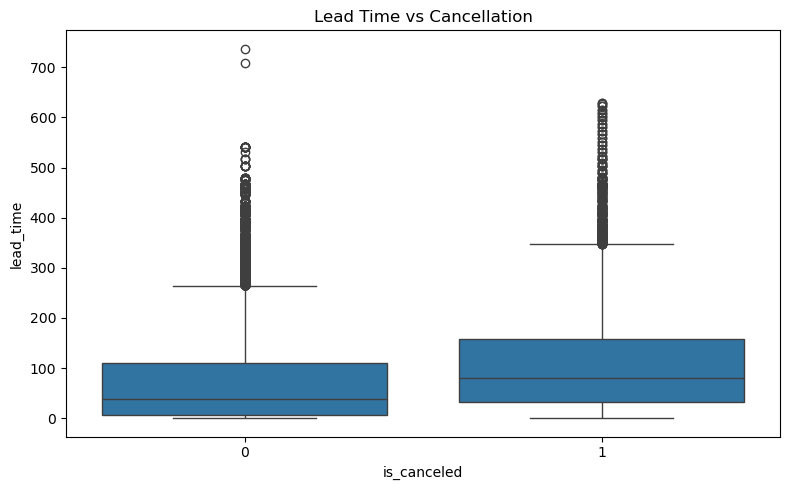

In [61]:
#Lead Time vs Cancellation
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.tight_layout()
plt.show()

# Bookings with longer lead times show higher cancellation rates.
# Early planners are more likely to cancel compared to last-minute bookings.

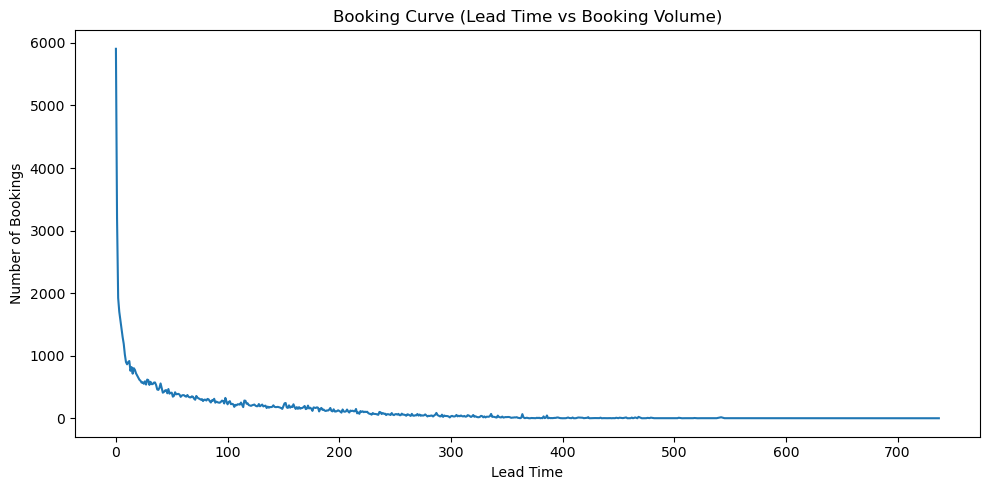

In [63]:
#BOOKING CURVE 
lead_time_counts = df.groupby('lead_time').size()

plt.figure(figsize=(10,5))
sns.lineplot(x=lead_time_counts.index, y=lead_time_counts.values)
plt.title("Booking Curve (Lead Time vs Booking Volume)")
plt.xlabel("Lead Time")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

#Shows when customers prefer to book
#Helps pricing strategy

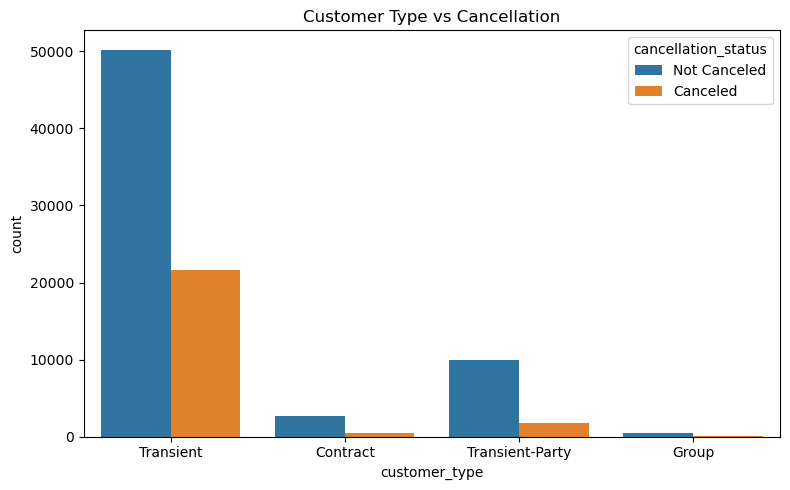

In [65]:
#CUSTOMER SEGMENTATION 
plt.figure(figsize=(8,5))
df['cancellation_status'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})
sns.countplot(x='customer_type', hue='cancellation_status', data=df)

plt.title("Customer Type vs Cancellation")
plt.tight_layout()
plt.show()

# Transient customers have the highest cancellation rate.
# Corporate and contract customers are more stable.

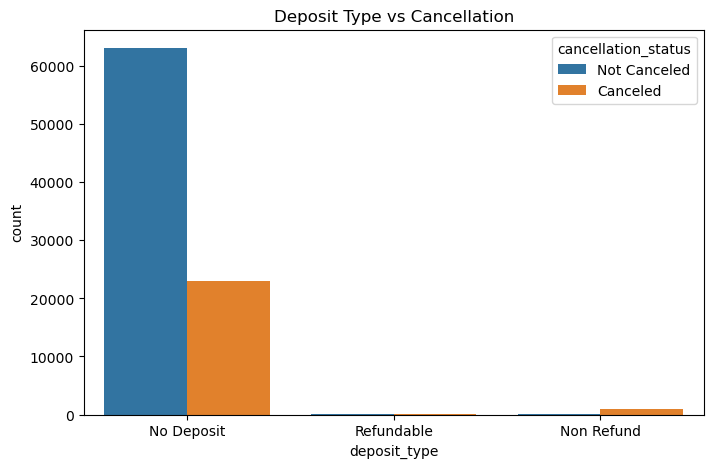

In [67]:
# Deposit Type vs Cancellation
plt.figure(figsize=(8,5))

sns.countplot(x='deposit_type', hue='cancellation_status', data=df)

plt.title("Deposit Type vs Cancellation")
plt.show()

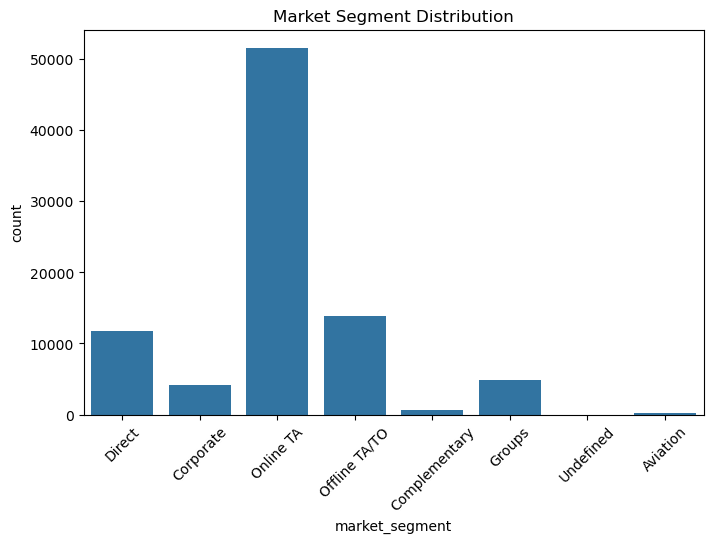

In [69]:
# Market Segment Analysis
plt.figure(figsize=(8,5))

sns.countplot(x='market_segment', data=df)

plt.xticks(rotation=45)
plt.title("Market Segment Distribution")
plt.show()

In [71]:
# Convert month to number
month_map = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}

df['month_num'] = df['arrival_date_month'].map(month_map)

# Create season
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month_num'].apply(get_season)

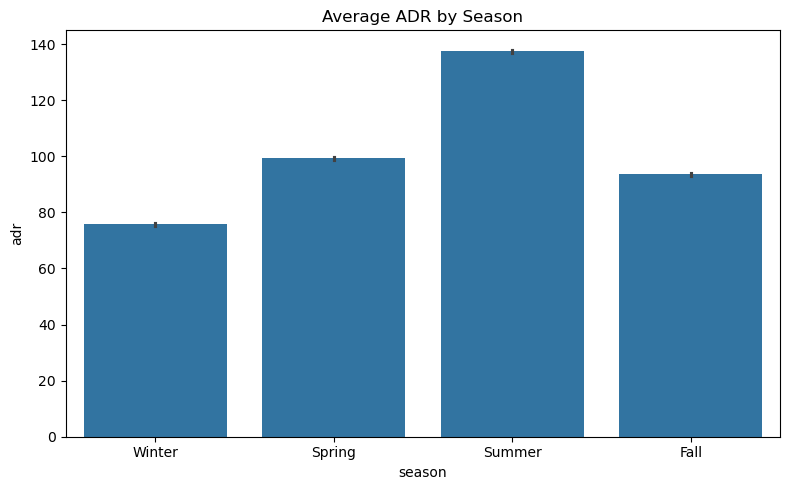

In [73]:
# Season vs ADR
plt.figure(figsize=(8,5))

sns.barplot(x='season', y='adr', data=df, order=['Winter','Spring','Summer','Fall'])

plt.title("Average ADR by Season")
plt.tight_layout()
plt.show()

# ADR tends to increase during peak seasons like Summer.
# Pricing strategies vary significantly across seasons.